In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from joblib import Parallel, delayed
import pandas as pd
import statsmodels.api as sm
import itertools
import time

### GLOBAL VARIABLES

In [4]:
# Element data
# ELEMENTS = ['SIO2', 'TIO2', 'B2O3', 'AL2O3', 'CR2O3', 'FE2O3', 'FEO', 'FEOT', 'CAO', 'MGO',
#             'MNO', 'NIO', 'K2O', 'NA2O', 'P2O5', 'H2O', 'CO2', 'CO1', 'F', 'CL', 'CL2', 'OH',
#             'CH4', 'SO2', 'SO3', 'SO4', 'S', 'LI', 'BE', 'B', 'C', 'NA', 'MG',
#             'AL', 'P', 'K', 'CA', 'SC', 'TI', 'V', 'CR', 'MN', 'FE', 'CO', 'NI', 'CU', 'ZN',
#             'GA', 'GE', 'AS', 'SE', 'BR', 'RB', 'SR', 'Y', 'ZR', 'NB', 'MO', 'RU', 'RH', 'PD',
#             'AG', 'CD', 'IN', 'SN', 'SB', 'TE', 'I', 'CS', 'BA', 'LA', 'CE', 'PR', 'ND', 'SM',
#             'EU', 'GD', 'TB', 'DY', 'HO', 'ER', 'TM', 'YB', 'LU', 'HF', 'TA', 'W', 'RE', 'OS',
#             'IR', 'PT', 'AU', 'HG', 'TL', 'PB', 'BI', 'TH', 'U']

ELEMENTS = ['SIO2', 'TIO2', 'AL2O3', 'CR2O3', 'FE2O3', 'FEO', 'FEOT', 'CAO', 'MGO',
            'MNO', 'NIO', 'K2O', 'NA2O', 'P2O5', 'F', 'CL', 'S', 'LI', 'BE', 'B', 'SC', 'TI', 
            'V', 'CR', 'MN', 'FE', 'CO', 'NI', 'CU', 'ZN',
            'GA', 'GE', 'AS', 'SE', 'BR', 'RB', 'SR', 'Y', 'ZR', 'NB', 'MO', 'RU', 'RH', 'PD',
            'AG', 'CD', 'IN', 'SN', 'SB', 'TE', 'CS', 'BA', 'LA', 'CE', 'PR', 'ND', 'SM',
            'EU', 'GD', 'TB', 'DY', 'HO', 'ER', 'TM', 'YB', 'LU', 'HF', 'TA', 'W', 'RE', 'OS',
            'IR', 'PT', 'AU', 'HG', 'TL', 'PB', 'BI', 'TH', 'U'] 

PPM_ELEMENTS = ['LI', 'BE', 'B', 'C', 'NA', 'MG', 'AL', 'P', 'K', 'CA', 'SC', 
                'TI', 'V', 'CR', 'MN', 'FE', 'CO', 'NI', 'CU', 'ZN', 'GA', 'GE', 'AS', 'SE',
                'BR', 'RB', 'SR', 'Y', 'ZR', 'NB', 'MO', 'RU', 'RH', 'PD', 'AG', 'CD', 'IN',
                'SN', 'SB', 'TE', 'I', 'CS', 'BA', 'LA', 'CE', 'PR', 'ND', 'SM', 'EU', 'GD',
                'TB', 'DY', 'HO', 'ER', 'TM', 'YB', 'LU', 'HF', 'TA', 'W', 'RE', 'OS', 'IR',
                'PT', 'AU', 'HG', 'TL', 'PB', 'BI', 'TH', 'U']

REE_ELEMENTS = ['LA', 'CE', 'PR', 'ND', 'SM', 'EU', 'GD', 'TB', 'DY', 'HO', 'ER', 'TM', 'YB', 'LU']

REE_ELEMENTS_LAMBDA = ['LA', 'CE', 'PR', 'ND', 'SM', 'GD', 'TB', 'DY', 'HO', 'ER', 'TM', 'YB', 'LU'] # exclude Eu

ELEMENTS_MASS = {
    'SIO2': 60.08,'TIO2': 79.87,'B2O3': 69.62,'AL2O3': 101.96,'CR2O3': 151.99,'FE2O3': 159.69,'FEO': 71.85,'FEOT': 87.85,'CAO': 56.08,'MGO': 40.30,'MNO': 70.94,'NIO': 74.71,
    'K2O': 94.20,'NA2O': 61.98,'P2O5': 141.94,'H2O': 18.02,'CO2': 44.01,'CO1': 28.01,'F': 18.99,'CL': 35.45,'CL2': 70.90,'OH': 17.01,
    'CH4': 16.04,'SO2': 64.07,'SO3': 80.06,'SO4': 96.06,'S': 32.07,'LI': 6.94,'BE': 9.01,'B': 10.81,'C': 12.01,'NA': 22.99,'MG': 24.31,'AL': 26.98,
    'P': 30.97,'K': 39.10,'CA': 40.08,'SC': 44.96,'TI': 47.87,'V': 50.94,'CR': 52.00,'MN': 54.94,'FE': 55.85,'CO': 58.93,'NI': 58.69,'CU': 63.55,
    'ZN': 65.38,'GA': 69.72,'GE': 72.63,'AS': 74.92,'SE': 78.97,'BR': 79.90,'RB': 85.47,'SR': 87.62,'Y': 88.91,'ZR': 91.22,'NB': 92.91,'MO': 95.94,'RU': 101.07,'RH': 102.91,'PD': 106.42,'AG': 107.87,
    'CD': 112.41,'IN': 114.82,'SN': 118.71,'SB': 121.76,'TE': 127.60,'I': 126.90,'CS': 132.91,'BA': 137.33,'LA': 138.91,
    'CE': 140.12,'PR': 140.91,'ND': 144.24,'SM': 150.36,'EU': 151.96,'GD': 157.25,'TB': 158.93,'DY': 162.50,'HO': 164.93,
    'ER': 167.26,'TM': 168.93,'YB': 173.05,'LU': 174.97,'HF': 178.49,'TA': 180.95,'W': 183.84,'RE': 186.21,'OS': 190.23,
    'IR': 192.22,'PT': 195.08,'AU': 196.97,'HG': 200.59,'TL': 204.38,'PB': 207.2,'BI': 208.98,'TH': 232.04,'U': 238.03}

# External datasets
CI_DATA = pd.read_csv('DATA/lambda_parameters.csv')
VOLCANO_DATABASE = pd.read_csv('DATA/GVP_HOLOCENE_VOLCS.csv')
df = pd.read_csv('DATA/georoc_arcs_modified.csv', low_memory=False)

### FUNCTIONS

In [6]:
##### OLS Regression
def perform_regression_for_group(group_name, group_data, independent_vars, dependent_vars):
    group_results = {}

    for x_var in independent_vars:
        for y_var in dependent_vars:
            if x_var == y_var:
                continue  # Skip if independent and dependent variables are the same

            # Select only the rows where both x_var and y_var are not NaN
            valid_rows = ~group_data[[x_var, y_var]].isna().any(axis=1)

            if valid_rows.sum() < 2:  # Need at least two data points to perform regression
                continue  # Skip this pair if not enough valid data points

            X = group_data.loc[valid_rows, x_var].values  # Independent variable
            y = group_data.loc[valid_rows, y_var].values  # Dependent variable

            if len(np.unique(X)) == 1:
                continue  # Skip if X has no variation (all values are the same)

            # Add a constant (intercept) to the model
            X_with_const = sm.add_constant(X)

            # Perform OLS linear regression
            model = sm.OLS(y, X_with_const).fit()

            if len(model.params) < 2:  # Check if there's a slope coefficient
                continue  # Skip if no slope (only an intercept)

            # Store the result (model, coefficients, intercept, p-values, etc.)
            group_results[(x_var, y_var)] = {
                'coefficients': model.params[1],  # Coefficient for the independent variable
                'intercept': model.params[0],  # Intercept
                'p_value': model.pvalues[1],  # p-value for the independent variable
                'r_squared': model.rsquared,  # R^2 score
                'mse': model.mse_resid, # mean squared error of the residuals
                'n_obs': model.nobs # number of observations
            }

    if group_results:
        return group_name, group_results
    else:
        return None  # Return None if no valid regressions were performed

def Regress_parallel(df, group_column, independent_vars, dependent_vars=None):
    grouped = df.groupby(group_column)

    if dependent_vars is None:
        # If no dependent variables specified, use all columns except independent vars and group column
        dependent_vars = [col for col in df.columns if col != group_column]

    # Parallel processing across groups
    results = Parallel(n_jobs=-1)(delayed(perform_regression_for_group)
        (group_name, group_data.drop(columns=[group_column]), independent_vars, dependent_vars)
        for group_name, group_data in grouped)

    # Filter out any None values from the results
    valid_results = [result for result in results if result is not None]

    # Convert list of tuples to dictionary
    results_dict = {group_name: result for group_name, result in valid_results}

    return results_dict

### PERFORM REGRESSION

In [8]:
# NOTE: this utilises all available cores, function will be faster if fewer cores are occupied
group_feature = 'VOLCANO'
independent_vars = [f'{i}_clr' for i in ['SIO2', 'MGO', 'ZR']]
dependent_vars = [f'{i}_clr' for i in ELEMENTS]

start = time.time()
results = Regress_parallel(df, group_feature, independent_vars, dependent_vars=dependent_vars)
end = time.time()
print(f'Performed {(len(independent_vars) * len(dependent_vars) * len(df.groupby(group_feature)))} regressions in {np.round((end-start), 2)} seconds')

Performed 103680 regressions in 30.9 seconds


### PREPARE FOR PLOTTING

In [13]:
def extract_result(results, regression_pair, parameter, threshold_parameter, threshold, threshold_parameter2, threshold2):
    if threshold_parameter == None and threshold_parameter2 == None:
        parameter_list = [results[group_item][regression_pair][parameter] for group_item in results.keys() if regression_pair in results[group_item]]
    elif threshold_parameter != None and threshold_parameter2 == None:
        parameter_list = [results[group_item][regression_pair][parameter] for group_item in results.keys() if regression_pair in results[group_item]             
        if results[group_item][regression_pair][threshold_parameter] > threshold]
    else:
        parameter_list = [results[group_item][regression_pair][parameter] for group_item in results.keys() if regression_pair in results[group_item]
                          if results[group_item][regression_pair][threshold_parameter] > threshold 
                          if results[group_item][regression_pair][threshold_parameter2] > threshold2]
    return parameter_list

def transpose_to_dict(results, regression_pairs, parameter, threshold_parameter = None, threshold = None, threshold_parameter2 = None, threshold2 = None):
    dict = {}
    for regression_pair in regression_pairs:
        dict[regression_pair] = extract_result(results, regression_pair, parameter, threshold_parameter, threshold, threshold_parameter2, threshold2)
    return dict

regression_pairs = [(x, y) for x, y in itertools.product(independent_vars, dependent_vars) if x != y]

def filter_dictionary_by_independent_var(old_dictionary, value):
    sub_dictionary = {key: old_dictionary[key] for key in old_dictionary.keys() if key[0] == value}
    return sub_dictionary

def filter_dictionary_by_length_of_groups(old_dictionary, min_length):
    sub_dictionary = {k: v for k, v in old_dictionary.items() if len(v) > min_length}
    return sub_dictionary

In [14]:
p_value_threshold = 0.95
n_samples_threshold = 5
min_length = 5

slopes = transpose_to_dict(results, regression_pairs, 'coefficients', 
                          threshold_parameter = 'p_value', threshold = p_value_threshold,
                          threshold_parameter2 = 'n_obs', threshold2 = n_samples_threshold)

### SLOPES PLOTTING

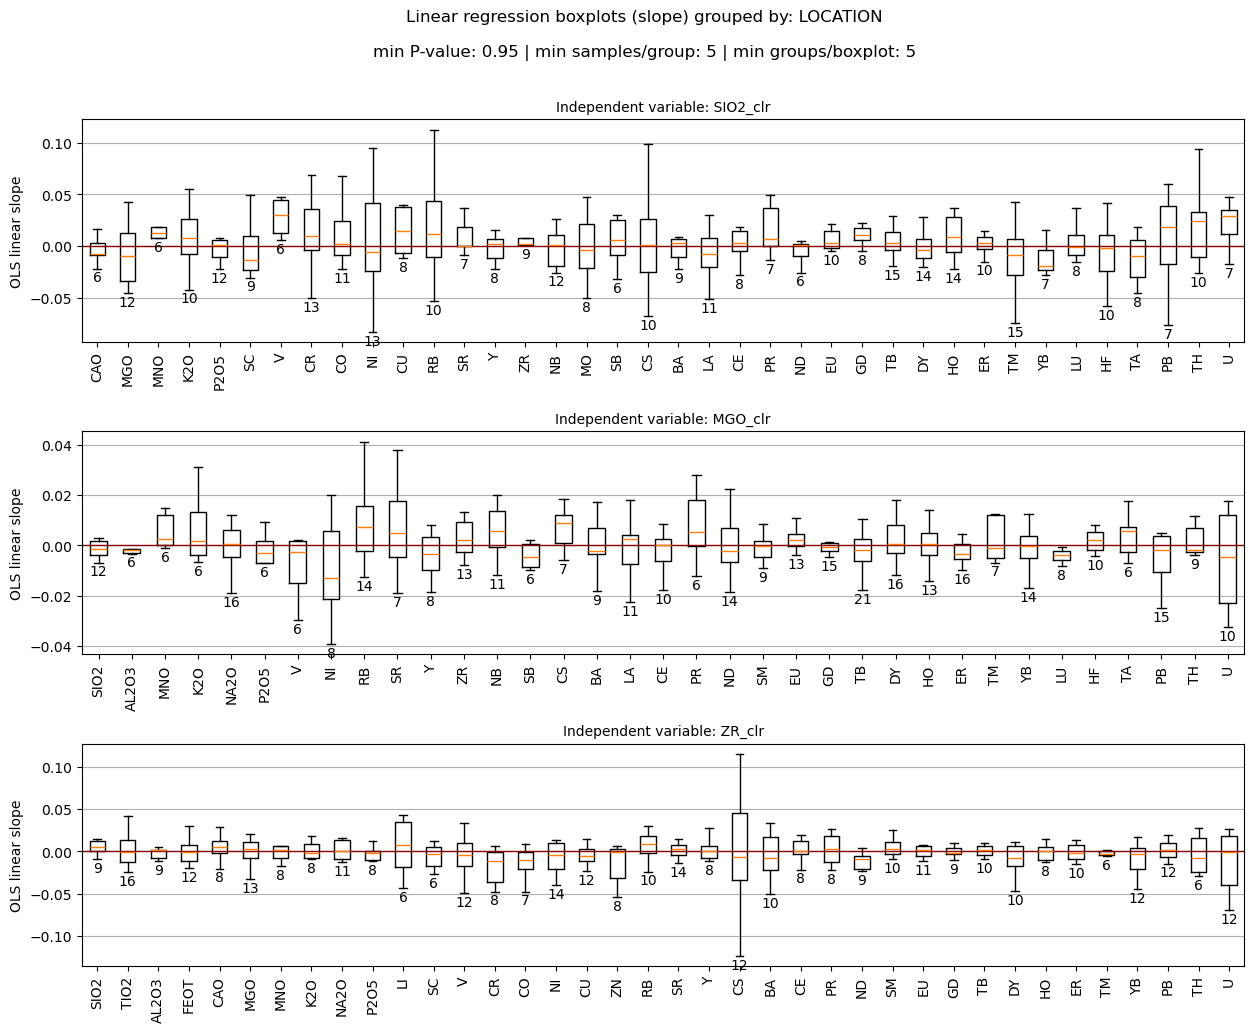

In [16]:
def plot_boxplot(axis, main_dict, independent_var, min_length = None):
    # filter data by independent variable
    data = filter_dictionary_by_independent_var(main_dict, independent_var)
    # filter data by minimum number of groups to form a box plot
    if min_length != None:
        data = filter_dictionary_by_length_of_groups(data, min_length)
    # turn this into two lists (keys and values)
    vals = [data[key] for key in data.keys()]
    labs = [i[1].split('_')[0] for i in list(data.keys())]
    # plot data
    boxplot = axis.boxplot(vals, showfliers=False)
    
    # Add the number of groups below the bottom whisker of each boxplot
    #axis.set_ylim(-0.5,0.5)
    ybuffer = (axis.get_ylim()[1] - axis.get_ylim()[0]) * 0.01
    for i, group_size in enumerate([len(v) for v in vals], start=1):
        whisker_min = boxplot['whiskers'][2*(i-1)].get_ydata()[1]
        axis.text(i, whisker_min - (ybuffer), str(group_size), 
                  ha='center', va='top', fontsize=10, color='k')
      
    # format plot
    axis.set_xticklabels(labs, rotation=90)
    axis.yaxis.grid(True)
    axis.axhline(0, color='darkred', lw=1)
    axis.set_title(f'Independent variable: {independent_var}', fontsize='medium')
    axis.set_ylabel('OLS linear slope')
    
fig = plt.figure(figsize=(15,(3*len(independent_vars)+2)))

fig.suptitle(f'Linear regression boxplots (slope) grouped by: {group_feature}\n\nmin P-value: {p_value_threshold} | min samples/group: {n_samples_threshold} | min groups/boxplot: {min_length}', fontsize='12')

axis_counter = 1
for independent_var in independent_vars: 
    
    ax = fig.add_subplot(len(independent_vars), 1, axis_counter)
    plot_boxplot(ax, slopes, independent_var, min_length=min_length)
    
    axis_counter += 1
    
fig.subplots_adjust(hspace=0.4)

plt.savefig(f'FIGURES/regression_slope_boxplots_{group_feature}.png', dpi=300)

plt.show()

### What about intercepts? Do they survive the center-log ratio transformation?
My suspicion is not...
To test empirically, lets plot intercepts from every group and element pair, both CLR transformed, and 'raw', against eachother. Will there be a relationship, and if so will it be linear?

In [673]:
# NOTE: this utilises all available cores, function will be faster if fewer cores are occupied
group_feature = 'VOLCANO'
independent_vars = [f'{i}_clr' for i in ['SIO2', 'MGO', 'ZR']]
dependent_vars = [f'{i}_clr' for i in ELEMENTS]

start = time.time()
CLR_results = Regress_parallel(df, group_feature, independent_vars, dependent_vars=dependent_vars)
end = time.time()
print(f'Performed {(len(independent_vars) * len(dependent_vars) * len(df.groupby(group_feature)))} regressions in {np.round((end-start), 2)} seconds')

independent_vars = [f'{i}_norm' for i in ['SIO2', 'MGO', 'ZR']]
dependent_vars = [f'{i}_norm' for i in ELEMENTS]

start = time.time()
NORM_results = Regress_parallel(df, group_feature, independent_vars, dependent_vars=dependent_vars)
end = time.time()
print(f'Performed {(len(independent_vars) * len(dependent_vars) * len(df.groupby(group_feature)))} regressions in {np.round((end-start), 2)} seconds')

Performed 108240 regressions in 13.06 seconds
Performed 108240 regressions in 12.95 seconds


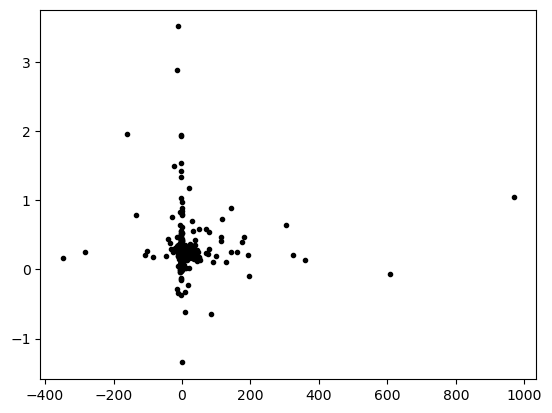

In [808]:
# convert to pandas dataframes
df_NORM = pd.DataFrame.from_dict(NORM_results, orient='index')
df_CLR = pd.DataFrame.from_dict(CLR_results, orient='index')

# merge the NORM and CLR dataframes by the group name
df_compare = df_NORM.merge(df_CLR, right_index=True, left_index=True)

# generate some new columsn of intercept data to compare
df_compare['SIO2_MGO_norm_intercept'] = df_compare['SIO2_norm', 'MGO_norm'].apply(lambda x: x['intercept'] if isinstance(x, dict) else None)
df_compare['SIO2_MGO_clr_intercept'] = df_compare['SIO2_clr', 'MGO_clr'].apply(lambda x: x['intercept'] if isinstance(x, dict) else None)

# plot the intercepts against eachother
fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(df_compare['SIO2_MGO_clr_intercept'], df_compare['SIO2_MGO_norm_intercept'], '.', color='k')

plt.show()

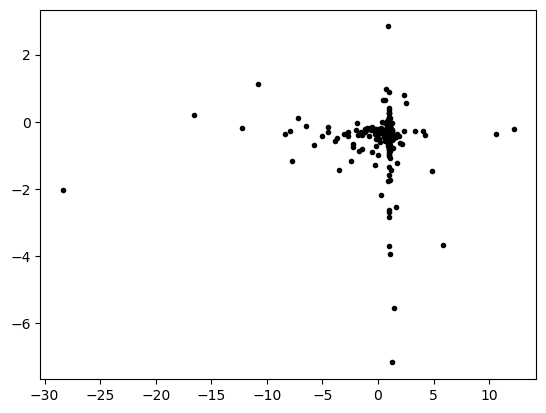

In [812]:
# convert to pandas dataframes
df_NORM = pd.DataFrame.from_dict(NORM_results, orient='index')
df_CLR = pd.DataFrame.from_dict(CLR_results, orient='index')

# merge the NORM and CLR dataframes by the group name
df_compare = df_NORM.merge(df_CLR, right_index=True, left_index=True)

# generate some new columsn of intercept data to compare
df_compare['SIO2_MGO_norm_coefficients'] = df_compare['SIO2_norm', 'MGO_norm'].apply(lambda x: x['coefficients'] if isinstance(x, dict) else None)
df_compare['SIO2_MGO_clr_coefficients'] = df_compare['SIO2_clr', 'MGO_clr'].apply(lambda x: x['coefficients'] if isinstance(x, dict) else None)

# plot the intercepts against eachother
fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(df_compare['SIO2_MGO_clr_coefficients'], df_compare['SIO2_MGO_norm_coefficients'], '.', color='k')

plt.show()

### LOCATION vs VOLCANO, which is a better grouping index?

In [115]:
group_feature = 'VOLCANO'
independent_vars = [f'{i}_clr' for i in ['SIO2', 'MGO', 'ZR']]
dependent_vars = [f'{i}_clr' for i in ELEMENTS]

start = time.time()
VOLCANO_results = Regress_parallel(df, group_feature, independent_vars, dependent_vars=dependent_vars)
end = time.time()
print(f'Performed {(len(independent_vars) * len(dependent_vars) * len(df.groupby(group_feature)))} regressions in {np.round((end-start), 2)} seconds')

group_feature = 'LOCATION'
independent_vars = [f'{i}_clr' for i in ['SIO2', 'MGO', 'ZR']]
dependent_vars = [f'{i}_clr' for i in ELEMENTS]

start = time.time()
LOCATION_results = Regress_parallel(df, group_feature, independent_vars, dependent_vars=dependent_vars)
end = time.time()
print(f'Performed {(len(independent_vars) * len(dependent_vars) * len(df.groupby(group_feature)))} regressions in {np.round((end-start), 2)} seconds')

Performed 103680 regressions in 49.91 seconds
Performed 647040 regressions in 278.58 seconds


In [207]:
VOLCANO_pvals = [VOLCANO_results[key][pair]['p_value'] for key in VOLCANO_results for pair in VOLCANO_results[key]]
LOCATION_pvals = [LOCATION_results[key][pair]['p_value'] for key in LOCATION_results for pair in LOCATION_results[key]]

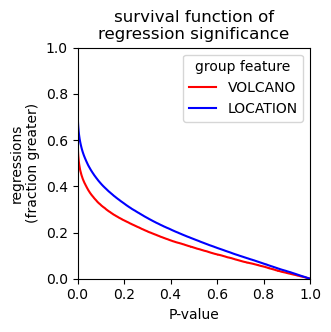

In [240]:
def clean_list(mylist):
    my_array = np.array(mylist)
    clean = my_array[~np.isnan(my_array)]
    return clean
    
fig = plt.figure(figsize=(3,3))

ax = fig.add_subplot(111)

ax.ecdf(clean_list(VOLCANO_pvals), complementary=True, 
        color='red', label='VOLCANO')
ax.ecdf(clean_list(LOCATION_pvals), complementary=True,
       color='blue', label='LOCATION')

ax.set_xlabel('P-value')
ax.set_ylabel('regressions\n(fraction greater)')
ax.set_title('survival function of\nregression significance')
ax.set_xlim(0,1)
ax.set_ylim(0,1)

ax.legend(title='group feature')

plt.savefig('FIGURES/survival_function_pval.png', dpi=300, bbox_inches='tight')
plt.show()

In [242]:
VOLCANO_r2 = [VOLCANO_results[key][pair]['r_squared'] for key in VOLCANO_results for pair in VOLCANO_results[key]]
LOCATION_r2 = [LOCATION_results[key][pair]['r_squared'] for key in LOCATION_results for pair in LOCATION_results[key]]

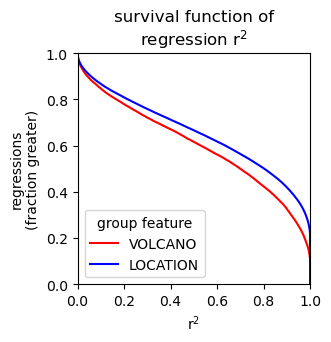

In [250]:
def clean_list(mylist):
    my_array = np.array(mylist)
    clean = my_array[~np.isnan(my_array)]
    return clean
    
fig = plt.figure(figsize=(3,3))

ax = fig.add_subplot(111)

ax.ecdf(clean_list(VOLCANO_r2), complementary=True, 
        color='red', label='VOLCANO')
ax.ecdf(clean_list(LOCATION_r2), complementary=True,
       color='blue', label='LOCATION')

ax.set_xlabel('r$^2$')
ax.set_ylabel('regressions\n(fraction greater)')
ax.set_title('survival function of\nregression r$^2$')
ax.set_xlim(0,1)
ax.set_ylim(0,1)

ax.legend(title='group feature')

plt.savefig('FIGURES/survival_function_r2.png', dpi=300, bbox_inches='tight')
plt.show()

In [246]:
VOLCANO_nobs = [VOLCANO_results[key][pair]['n_obs'] for key in VOLCANO_results for pair in VOLCANO_results[key]]
LOCATION_nobs = [LOCATION_results[key][pair]['n_obs'] for key in LOCATION_results for pair in LOCATION_results[key]]

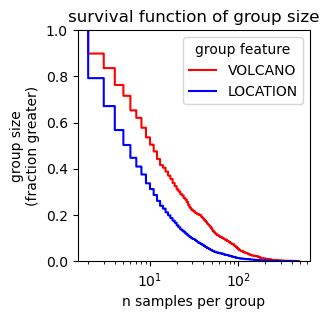

In [256]:
def clean_list(mylist):
    my_array = np.array(mylist)
    clean = my_array[~np.isnan(my_array)]
    return clean
    
fig = plt.figure(figsize=(3,3))

ax = fig.add_subplot(111)

ax.ecdf(clean_list(VOLCANO_nobs), complementary=True, 
        color='red', label='VOLCANO')
ax.ecdf(clean_list(LOCATION_nobs), complementary=True,
       color='blue', label='LOCATION')

ax.set_xlabel('n samples per group')
ax.set_ylabel('group size\n(fraction greater)')
ax.set_title('survival function of group size')
#ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.set_xscale('log')

ax.legend(title='group feature')

plt.savefig('FIGURES/survival_function_nobs.png', dpi=300, bbox_inches='tight')
plt.show()

In [266]:
np.median(LOCATION_nobs)

6.0

In [268]:
print(len(LOCATION_nobs), len(VOLCANO_nobs))

194931 38783


In [272]:
len(LOCATION_results.keys())

1954